In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("✅ Libraries Loaded!")

✅ Libraries Loaded!


In [18]:
df = pd.read_csv('AB_NYC_2019.csv')

print("✅ Dataset Loaded!")
print("Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

✅ Dataset Loaded!
Shape: (48895, 16)

First 5 rows:


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [19]:
print("=== DATASET INFO ===")
print(df.info())

print("\n=== COLUMN NAMES ===")
print(df.columns.tolist())

print("\n=== MISSING VALUES BEFORE CLEANING ===")
print(df.isnull().sum())

print("\n=== DUPLICATE ROWS ===")
print("Duplicates:", df.duplicated().sum())

print("\n=== BASIC STATS ===")
print(df.describe())

=== DATASET INFO ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review

In [20]:
print("=== BEFORE CLEANING ===")
print("Shape:", df.shape)
print("Missing values:", df.isnull().sum().sum())

# Step 1: Fill missing 'name' with 'Unknown'
df['name'].fillna('Unknown', inplace=True)

# Step 2: Fill missing 'host_name' with 'Unknown'
df['host_name'].fillna('Unknown', inplace=True)

# Step 3: Fill missing 'reviews_per_month' with 0
df['reviews_per_month'].fillna(0, inplace=True)

# Step 4: Fill missing 'last_review' with 'No Review'
df['last_review'].fillna('No Review', inplace=True)

# Step 5: Remove duplicate rows
df = df.drop_duplicates()

# Step 6: Remove rows where price = 0 (invalid data)
df = df[df['price'] > 0]

# Step 7: Remove extreme outliers in price
df = df[df['price'] < 10000]

# Step 8: Remove extreme outliers in minimum_nights
df = df[df['minimum_nights'] <= 365]

print("\n=== AFTER CLEANING ===")
print("Shape:", df.shape)
print("Missing values:", df.isnull().sum().sum())
print("✅ Data Cleaned Successfully!")

=== BEFORE CLEANING ===
Shape: (48895, 16)
Missing values: 20141

=== AFTER CLEANING ===
Shape: (48867, 16)
Missing values: 0
✅ Data Cleaned Successfully!


/tmp/ipykernel_7859/1777852932.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['name'].fillna('Unknown', inplace=True)
/tmp/ipykernel_7859/1777852932.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 

In [21]:
print("=== MISSING VALUES AFTER CLEANING ===")
print(df.isnull().sum())

print("\n=== DATA TYPES ===")
print(df.dtypes)

print("\n=== PRICE STATS AFTER CLEANING ===")
print("Min Price: $", df['price'].min())
print("Max Price: $", df['price'].max())
print("Mean Price: $", round(df['price'].mean(), 2))
print("Median Price: $", df['price'].median())

print("\n✅ Verification Complete!")

=== MISSING VALUES AFTER CLEANING ===
id                                0
name                              0
host_id                           0
host_name                         0
neighbourhood_group               0
neighbourhood                     0
latitude                          0
longitude                         0
room_type                         0
price                             0
minimum_nights                    0
number_of_reviews                 0
last_review                       0
reviews_per_month                 0
calculated_host_listings_count    0
availability_365                  0
dtype: int64

=== DATA TYPES ===
id                                  int64
name                               object
host_id                             int64
host_name                          object
neighbourhood_group                object
neighbourhood                      object
latitude                          float64
longitude                         float64
room_type        

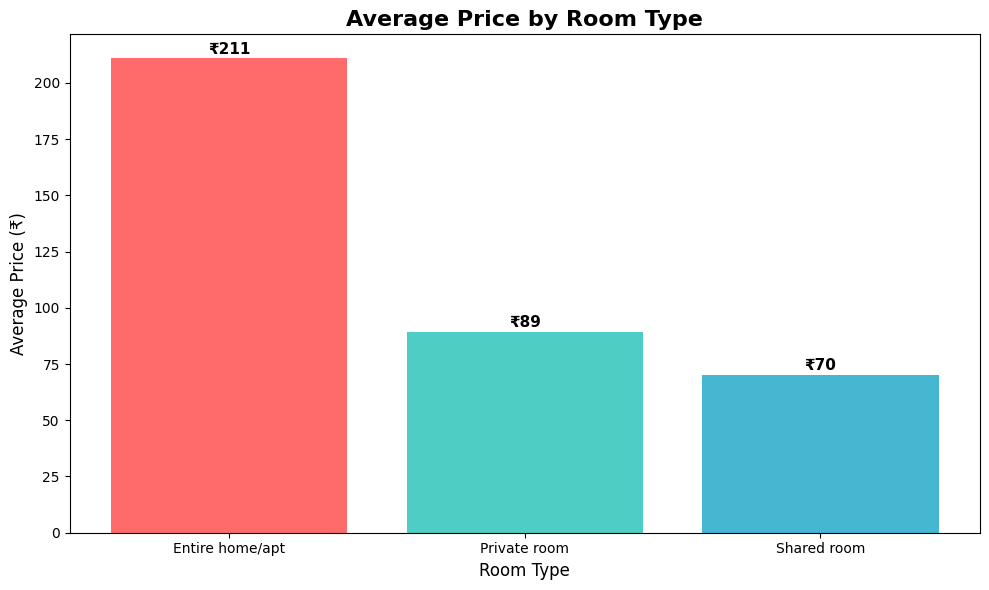

✅ Chart 1 Saved!


In [22]:
plt.figure(figsize=(10,6))
room_price = df.groupby('room_type')['price'].mean().sort_values(ascending=False)
bars = plt.bar(room_price.index, room_price.values,
               color=['#FF6B6B','#4ECDC4','#45B7D1'])
plt.title('Average Price by Room Type', fontsize=16, fontweight='bold')
plt.xlabel('Room Type', fontsize=12)
plt.ylabel('Average Price (₹)', fontsize=12)
for bar, val in zip(bars, room_price.values):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 2,
             f'₹{val:.0f}', ha='center',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('chart1_price_by_room.png', dpi=150)
plt.show()
print("✅ Chart 1 Saved!")

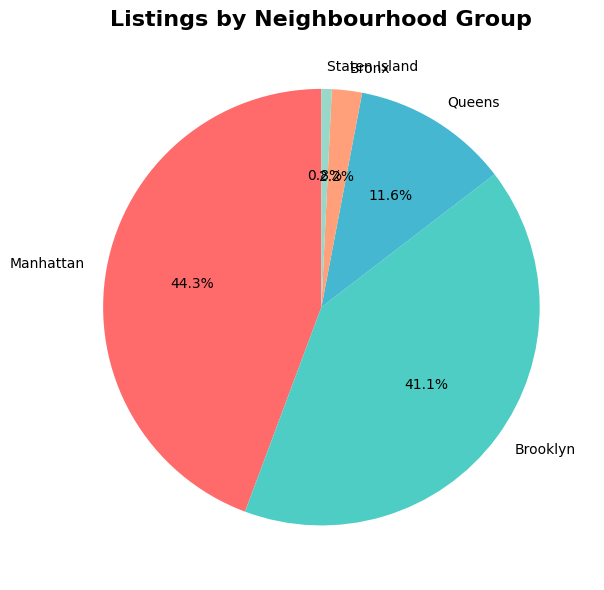

✅ Chart 2 Saved!


In [23]:
plt.figure(figsize=(10,6))
neighbourhood_count = df['neighbourhood_group'].value_counts()
plt.pie(neighbourhood_count.values,
        labels=neighbourhood_count.index,
        autopct='%1.1f%%',
        colors=['#FF6B6B','#4ECDC4','#45B7D1','#FFA07A','#98D8C8'],
        startangle=90)
plt.title('Listings by Neighbourhood Group', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('chart2_neighbourhood.png', dpi=150)
plt.show()
print("✅ Chart 2 Saved!")

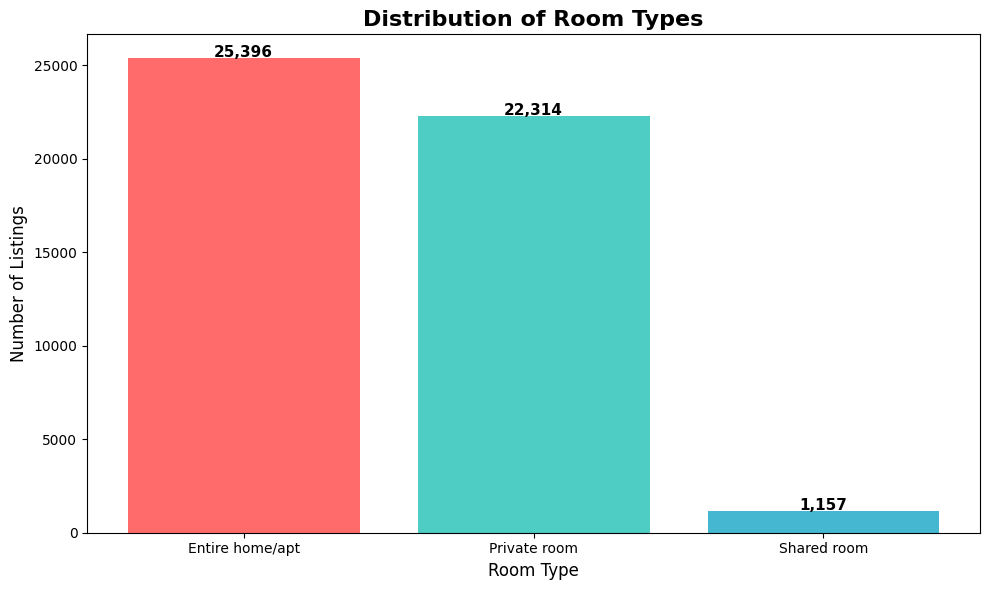

✅ Chart 3 Saved!


In [24]:
plt.figure(figsize=(10,6))
room_count = df['room_type'].value_counts()
bars = plt.bar(room_count.index, room_count.values,
               color=['#FF6B6B','#4ECDC4','#45B7D1'])
plt.title('Distribution of Room Types', fontsize=16, fontweight='bold')
plt.xlabel('Room Type', fontsize=12)
plt.ylabel('Number of Listings', fontsize=12)
for bar, val in zip(bars, room_count.values):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 50,
             f'{val:,}', ha='center',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('chart3_room_type.png', dpi=150)
plt.show()
print("✅ Chart 3 Saved!")

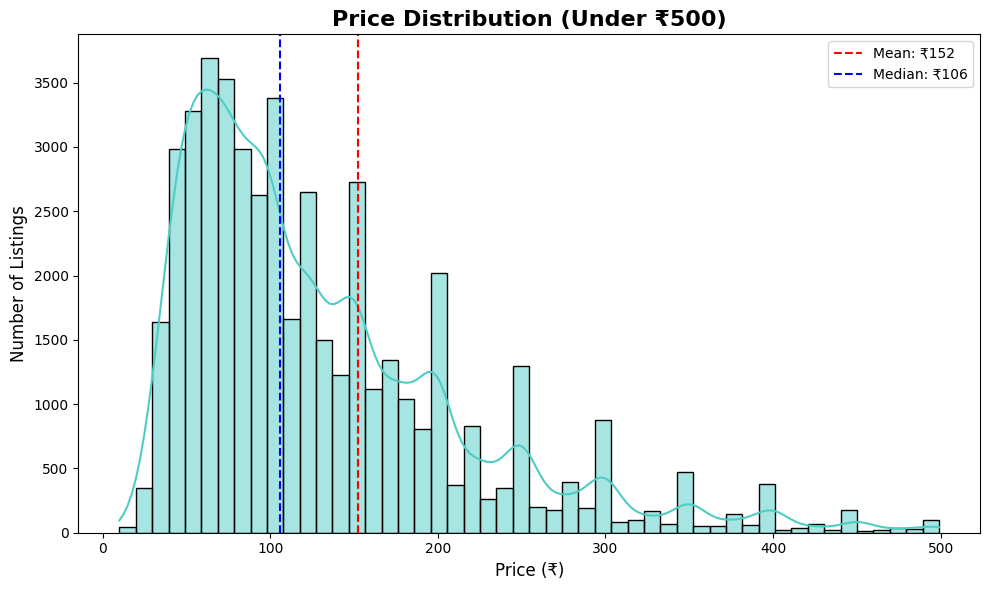

✅ Chart 4 Saved!


In [25]:
plt.figure(figsize=(10,6))
sns.histplot(df[df['price'] < 500]['price'],
             bins=50, color='#4ECDC4', kde=True)
plt.title('Price Distribution (Under ₹500)', fontsize=16, fontweight='bold')
plt.xlabel('Price (₹)', fontsize=12)
plt.ylabel('Number of Listings', fontsize=12)
plt.axvline(df['price'].mean(), color='red',
            linestyle='--',
            label=f'Mean: ₹{df["price"].mean():.0f}')
plt.axvline(df['price'].median(), color='blue',
            linestyle='--',
            label=f'Median: ₹{df["price"].median():.0f}')
plt.legend()
plt.tight_layout()
plt.savefig('chart4_price_dist.png', dpi=150)
plt.show()
print("✅ Chart 4 Saved!")

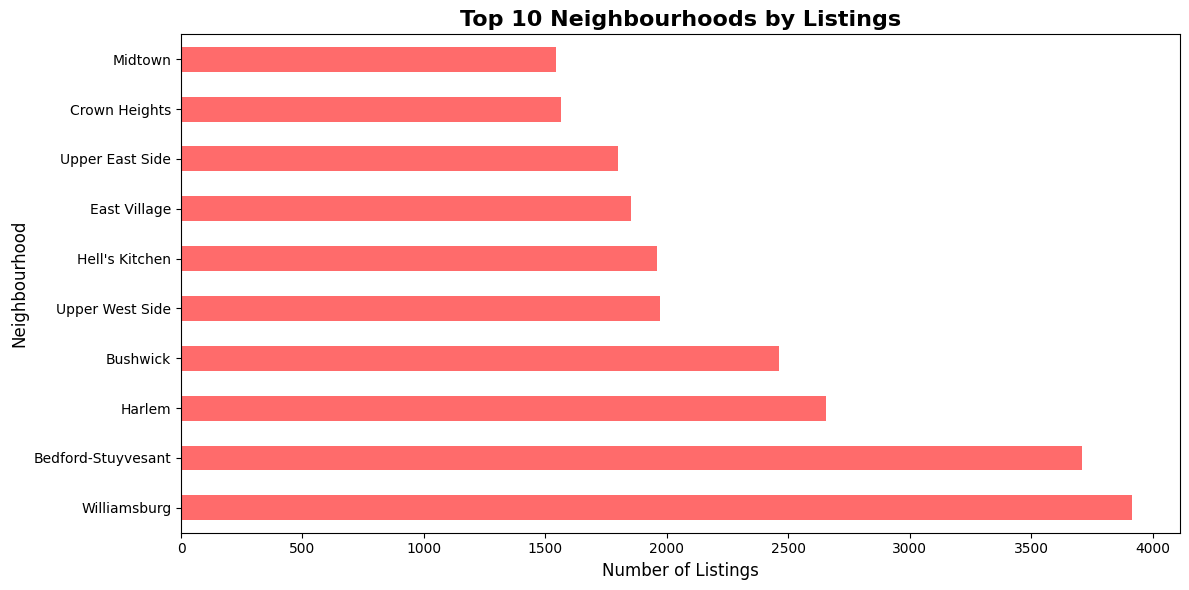

✅ Chart 5 Saved!


In [26]:
plt.figure(figsize=(12,6))
top_neighbourhoods = df['neighbourhood'].value_counts().head(10)
top_neighbourhoods.plot(kind='barh', color='#FF6B6B')
plt.title('Top 10 Neighbourhoods by Listings', fontsize=16, fontweight='bold')
plt.xlabel('Number of Listings', fontsize=12)
plt.ylabel('Neighbourhood', fontsize=12)
plt.tight_layout()
plt.savefig('chart5_top_neighbourhoods.png', dpi=150)
plt.show()
print("✅ Chart 5 Saved!")

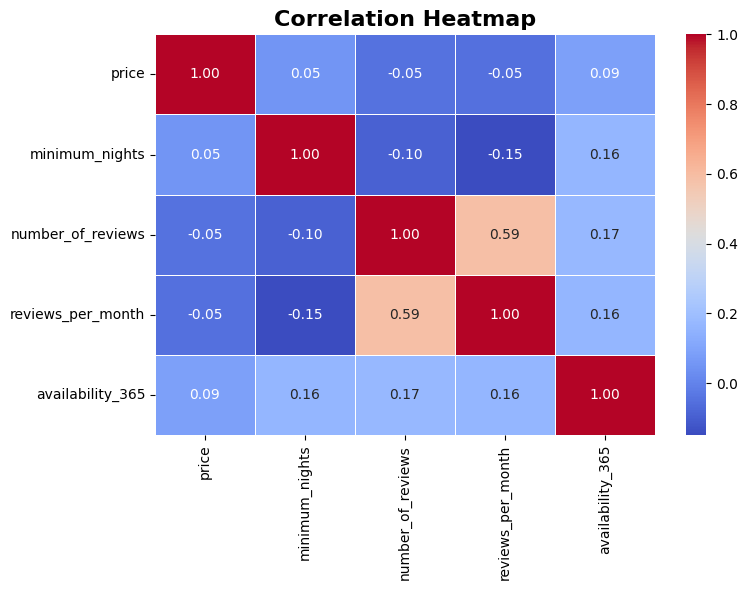

✅ Chart 6 Saved!


In [27]:
plt.figure(figsize=(8,6))
numeric_df = df[['price','minimum_nights',
                  'number_of_reviews',
                  'reviews_per_month',
                  'availability_365']]
sns.heatmap(numeric_df.corr(), annot=True,
            cmap='coolwarm', fmt='.2f',
            linewidths=0.5)
plt.title('Correlation Heatmap', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('chart6_heatmap.png', dpi=150)
plt.show()
print("✅ Chart 6 Saved!")

In [28]:
print("=" * 50)
print("📊 KEY INSIGHTS & RECOMMENDATIONS")
print("=" * 50)

top_neighbourhood = df['neighbourhood_group'].value_counts().idxmax()
top_room = df['room_type'].value_counts().idxmax()
avg_price = round(df['price'].mean(), 2)
total_listings = len(df)
most_expensive = df.groupby('room_type')['price'].mean().idxmax()

print(f"\n1. 🏠 Total Listings Analyzed: {total_listings:,}")
print(f"2. 🏆 Most Popular Area: {top_neighbourhood}")
print(f"3. 🛏️ Most Common Room Type: {top_room}")
print(f"4. 💰 Average Price: ${avg_price}")
print(f"5. 💎 Most Expensive Room Type: {most_expensive}")

print("\n📌 RECOMMENDATIONS:")
print(f"   → Invest in {top_neighbourhood} - most listings & demand")
print(f"   → {most_expensive} rooms generate highest revenue")
print(f"   → Price listings competitively around ${avg_price}")
print(f"   → Focus on getting more reviews to increase bookings")

📊 KEY INSIGHTS & RECOMMENDATIONS

1. 🏠 Total Listings Analyzed: 48,867
2. 🏆 Most Popular Area: Manhattan
3. 🛏️ Most Common Room Type: Entire home/apt
4. 💰 Average Price: $152.15
5. 💎 Most Expensive Room Type: Entire home/apt

📌 RECOMMENDATIONS:
   → Invest in Manhattan - most listings & demand
   → Entire home/apt rooms generate highest revenue
   → Price listings competitively around $152.15
   → Focus on getting more reviews to increase bookings
